<p align="right">
  <img src="Zewail-City.png">
</p>


---

# __Problem set #2__

In [1]:
# Mian Libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm, poisson
from scipy.optimize import curve_fit

### Problem 1: Probability with Dice

In [2]:
# Simulate rolling a fair six-sided die 10,000 times
N = 10000
dice = np.random.randint(1, 7, size=N)

# Compute histogram and empirical probabilities
counts, bins = np.histogram(dice, bins=np.arange(1, 8) - 0.5)
prob_emp = counts / counts.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2.0

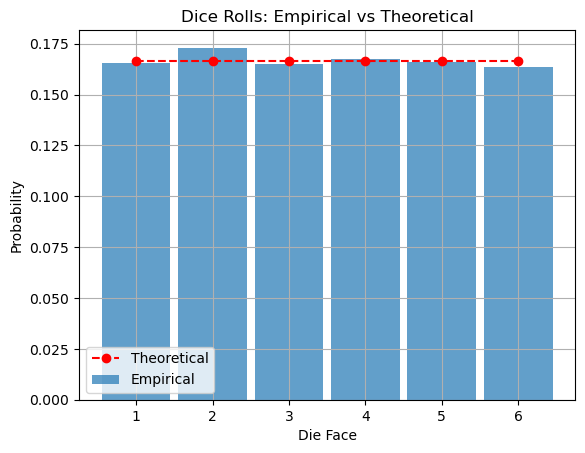

In [3]:
# Plot empirical probabilities
plt.bar(bin_centers, prob_emp, width=0.9, alpha=0.7, label="Empirical")

# Plot theoretical probability (1/6 for each face)
plt.plot(bin_centers, [1/6] * len(bin_centers), marker='o', linestyle='--', color='red', label="Theoretical")

plt.xlabel("Die Face")
plt.ylabel("Probability")
plt.title("Dice Rolls: Empirical vs Theoretical")
plt.legend()
plt.grid(True)
plt.show()

---

### Problem 2: Binomial Distribution

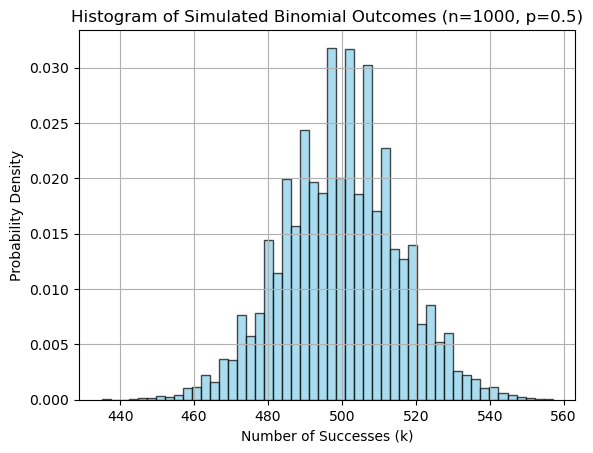

In [4]:
# Parameters
n, p = 1000, 0.5  # number of coin flips and probability of heads
N_samples = 10000  # number of simulations

# Simulate binomial outcomes: number of heads in 1000 flips, repeated 10,000 times
samples = np.random.binomial(n, p, size=N_samples)

# Plot histogram of simulated results
plt.hist(samples, bins=50, density=True, alpha=0.7, color="skyblue", edgecolor="black")
plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability Density")
plt.title(f"Histogram of Simulated Binomial Outcomes (n={n}, p={p})")
plt.grid(True)
plt.show()


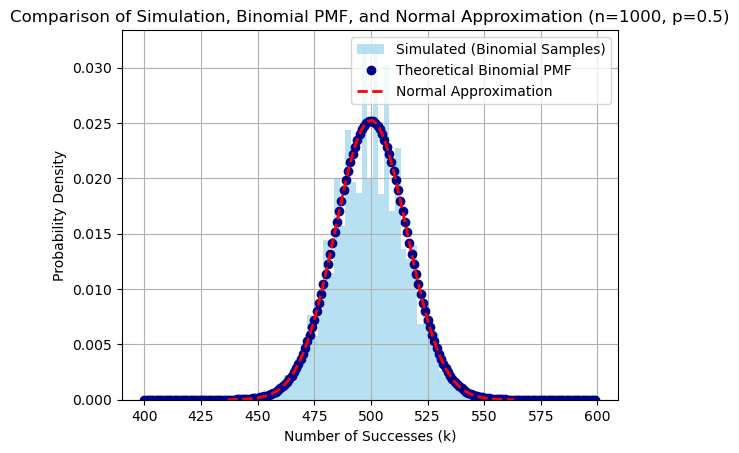

In [5]:
# Compute theoretical binomial PMF
k = np.arange(400, 600)
pmf_binom = binom.pmf(k, n, p)

# Normal approximation
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
pdf_normal = norm.pdf(x, mu, sigma)

# Plot histogram again for context
plt.hist(samples, bins=50, density=True, alpha=0.6, color="skyblue", label="Simulated (Binomial Samples)")

# Overlay theoretical binomial PMF
plt.plot(k, pmf_binom, 'o', color='darkblue', label="Theoretical Binomial PMF")

# Overlay normal approximation
plt.plot(x, pdf_normal, 'r--', linewidth=2, label="Normal Approximation")

plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability Density")
plt.title(f"Comparison of Simulation, Binomial PMF, and Normal Approximation (n={n}, p={p})")
plt.legend()
plt.grid(True)
plt.show()


---

### Problem 3: Poisson Distribution

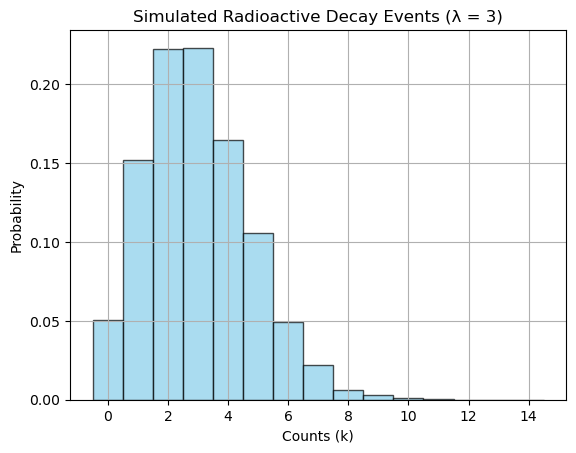

In [6]:
# Parameters
lam = 3  # mean rate (λ)
N_samples = 10000  # number of simulations

# Simulate radioactive decay events (Poisson-distributed counts)
samples = np.random.poisson(lam, N_samples)

# Plot histogram of simulated counts
plt.hist(samples, bins=np.arange(-0.5, 15.5, 1), density=True, alpha=0.7, color="skyblue", edgecolor="black")
plt.xlabel("Counts (k)")
plt.ylabel("Probability")
plt.title(f"Simulated Radioactive Decay Events (λ = {lam})")
plt.grid(True)
plt.show()

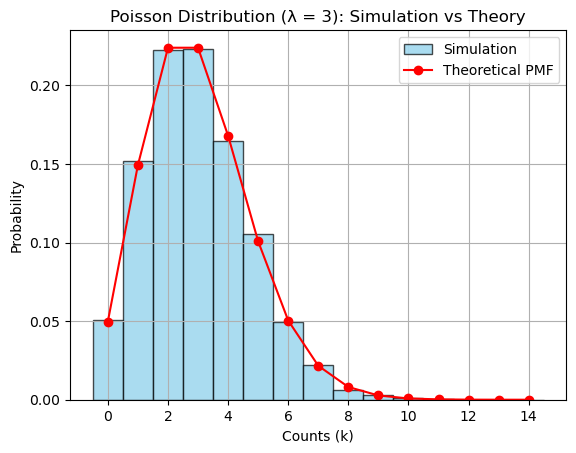

In [7]:
# Compute theoretical Poisson PMF
x = np.arange(0, 15)
pmf = poisson.pmf(x, lam)

# Plot both empirical and theoretical distributions
plt.hist(samples, bins=np.arange(-0.5, 15.5, 1), density=True, alpha=0.7, color="skyblue", edgecolor="black", label="Simulation")
plt.plot(x, pmf, marker='o', linestyle='-', color='red', label="Theoretical PMF")

plt.xlabel("Counts (k)")
plt.ylabel("Probability")
plt.title(f"Poisson Distribution (λ = {lam}): Simulation vs Theory")
plt.legend()
plt.grid(True)
plt.show()

---

### Problem 4: Central Limit Theorem

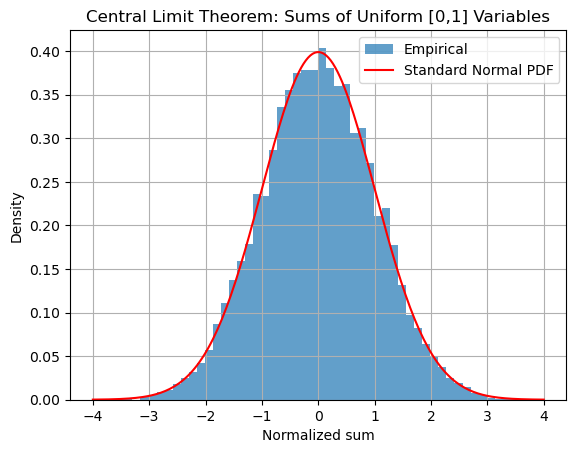

In [8]:
# Parameters
n_trials = 10000   # number of experiments
n_sums = 30        # number of samples per experiment

# Draw random samples from a uniform distribution [0, 1]
samples = np.random.rand(n_trials, n_sums)

# Compute the sum of each group (axis=1 sums across each trial)
sums = np.sum(samples, axis=1)

# Normalize the sums to have mean 0 and std 1
sums_norm = (sums - np.mean(sums)) / np.std(sums)

# Plot the histogram of normalized sample means
plt.hist(sums_norm, bins=50, density=True, alpha=0.7, label="Empirical")

# Compare with the standard normal (Gaussian) PDF
x = np.linspace(-4, 4, 200)
plt.plot(x, norm.pdf(x, 0, 1), 'r-', label="Standard Normal PDF")

# Labels and title
plt.xlabel("Normalized sum")
plt.ylabel("Density")
plt.title("Central Limit Theorem: Sums of Uniform [0,1] Variables")
plt.legend()
plt.grid(True)
plt.show()

---

### Problem 5: Error Propagation

In [9]:
# Given values and their uncertainties
x, sx = 2.0, 0.1
y, sy = 3.0, 0.2
z = x * y

#  Analytic propagation using partial derivatives

# For z = x * y, uncertainty is:  σ_z² = (y·σ_x)² + (x·σ_y)²

sigma_z = np.sqrt((y * sx)**2 + (x * sy)**2)
print("Analytic: z = {:.3f} ± {:.3f}".format(z, sigma_z))

Analytic: z = 6.000 ± 0.500


In [10]:
# Monte Carlo simulation 
N = 200000
x_samples = np.random.normal(x, sx, size=N)
y_samples = np.random.normal(y, sy, size=N)
z_samples = x_samples * y_samples

print("Monte Carlo: z = {:.3f} ± {:.3f}".format(np.mean(z_samples), np.std(z_samples)))

Monte Carlo: z = 5.999 ± 0.501


---

### Problem 6: Gaussian Fitting

In [11]:
# Generate noisy Gaussian data
np.random.seed(0)  # for reproducibility
mu_true, sigma_true = 5, 2
N = 1000

# True Gaussian data + noise
x = np.linspace(0, 10, N)
y_true = np.exp(-(x - mu_true)**2 / (2 * sigma_true**2))
noise = 0.05 * np.random.normal(size=N)
y_noisy = y_true + noise

# Define Gaussian function for fitting
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


In [12]:
# Perform curve fitting
popt, pcov = curve_fit(gaussian, x, y_noisy, p0=[1, 5, 2])
A_fit, mu_fit, sigma_fit = popt
A_err, mu_err, sigma_err = np.sqrt(np.diag(pcov))

# Print fitted parameters vs true values
print(f"True parameters:     μ = {mu_true:.2f}, σ = {sigma_true:.2f}")
print(f"Fitted parameters:   μ = {mu_fit:.2f} ± {mu_err:.2f}, σ = {sigma_fit:.2f} ± {sigma_err:.2f}")

True parameters:     μ = 5.00, σ = 2.00
Fitted parameters:   μ = 5.00 ± 0.01, σ = 2.00 ± 0.01


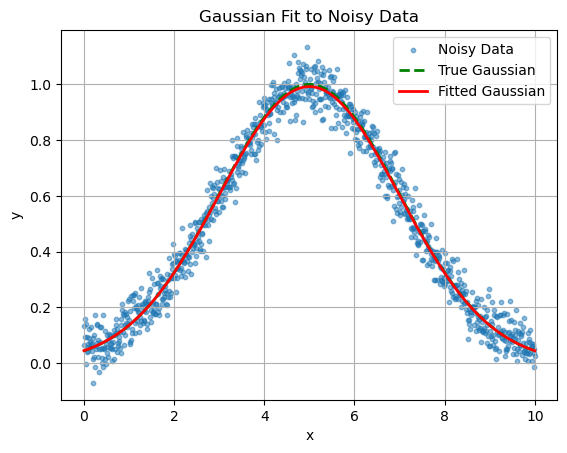

In [13]:
# Plot data and fitted curve 
plt.scatter(x, y_noisy, s=10, alpha=0.5, label="Noisy Data")
plt.plot(x, y_true, 'g--', linewidth=2, label="True Gaussian")
plt.plot(x, gaussian(x, *popt), 'r', linewidth=2, label="Fitted Gaussian")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Fit to Noisy Data")
plt.legend()
plt.grid(True)
plt.show()


---